In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score
from sklearn.datasets import fetch_openml
import gzip
import pickle

In [ ]:
!pip install matplotlib

In [ ]:
!pip install scikit-learn

In [3]:
with gzip.open("datasets/mnist.pkl.gz", 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print(type(data))

if isinstance(data, tuple):
    print(f"O arquivo contém {len(data)} elementos.")

    # Inspecionar os primeiros elementos
    for i, element in enumerate(data):
        print(f"Elemento {i}: {type(element)}")
        if isinstance(element, (list, np.ndarray)):
            print(f"Forma do elemento {i}: {len(element)} elementos")


<class 'tuple'>
O arquivo contém 3 elementos.
Elemento 0: <class 'tuple'>
Elemento 1: <class 'tuple'>
Elemento 2: <class 'tuple'>


In [4]:
for i, element in enumerate(data):
    print(f"Elemento {i}: Tipo = {type(element)}")

    if isinstance(element, (tuple, list)):
        print(f"Tamanho do Elemento {i}: {len(element)} elementos")
        for j, subelement in enumerate(element):
            if hasattr(subelement, '__len__'):
                print(f"  Subelemento {j}: Tipo = {type(subelement)} - Tamanho = {len(subelement)}")
            else:
                print(f"  Subelemento {j}: Tipo = {type(subelement)} - Tamanho = N/A")
    elif isinstance(element, np.ndarray):
        print(f"Forma do Elemento {i}: {element.shape}")


Elemento 0: Tipo = <class 'tuple'>
Tamanho do Elemento 0: 2 elementos
  Subelemento 0: Tipo = <class 'numpy.ndarray'> - Tamanho = 50000
  Subelemento 1: Tipo = <class 'numpy.ndarray'> - Tamanho = 50000
Elemento 1: Tipo = <class 'tuple'>
Tamanho do Elemento 1: 2 elementos
  Subelemento 0: Tipo = <class 'numpy.ndarray'> - Tamanho = 10000
  Subelemento 1: Tipo = <class 'numpy.ndarray'> - Tamanho = 10000
Elemento 2: Tipo = <class 'tuple'>
Tamanho do Elemento 2: 2 elementos
  Subelemento 0: Tipo = <class 'numpy.ndarray'> - Tamanho = 10000
  Subelemento 1: Tipo = <class 'numpy.ndarray'> - Tamanho = 10000


Treinamento: (50000, 784) (50000,)
Teste: (20000, 784) (20000,)


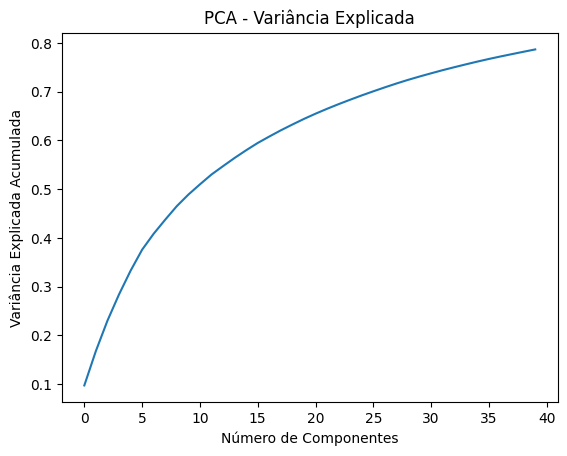

In [5]:
X_train = data[0][0]
y_train = data[0][1]
X_test = np.concatenate((data[1][0], data[2][0]), axis=0)
y_test = np.concatenate((data[1][1], data[2][1]), axis=0)

print("Treinamento:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

pca = PCA(n_components=40)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Visualização da variância explicada
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.title('PCA - Variância Explicada')
plt.show()

In [22]:
# K-means
kmeans_original = KMeans(n_clusters=10, random_state=42).fit(X_train)
kmeans_pca = KMeans(n_clusters=10, random_state=42).fit(X_train_pca)

ari_kmeans_original = adjusted_rand_score(y_train, kmeans_original.labels_)
ari_kmeans_pca = adjusted_rand_score(y_train, kmeans_pca.labels_)

print("Índice Rand Ajustado - K-means: Original vs PCA:", ari_kmeans_original, "vs", ari_kmeans_pca)

Índice Rand Ajustado - K-means: Original vs PCA: 0.39997936572635373 vs 0.35698309599915806


In [6]:
# DBSCAN
dbscan_original = DBSCAN(eps=5, min_samples=20).fit(X_train)
dbscan_pca = DBSCAN(eps=4, min_samples=10).fit(X_train_pca)

ari_dbscan_original = adjusted_rand_score(y_train, dbscan_original.labels_)
ari_dbscan_pca = adjusted_rand_score(y_train, dbscan_pca.labels_)

print("Índice Rand Ajustado - DBSCAN: Original vs PCA:", ari_dbscan_original, "vs", ari_dbscan_pca)

Índice Rand Ajustado - DBSCAN: Original vs PCA: 0.07490111620545668 vs 0.006050451876334037


In [24]:
# Clustering Hierárquico
hierarchical_original = AgglomerativeClustering(n_clusters=10).fit(X_train)
hierarchical_pca = AgglomerativeClustering(n_clusters=10).fit(X_train_pca)

ari_hierarchical_original = adjusted_rand_score(y_train, hierarchical_original.labels_)
ari_hierarchical_pca = adjusted_rand_score(y_train, hierarchical_pca.labels_)

print("Índice Rand Ajustado - Hierárquico: Original vs PCA:", ari_hierarchical_original, "vs", ari_hierarchical_pca)

Índice Rand Ajustado - Hierárquico: Original vs PCA: 0.5118889791532178 vs 0.533807481688097


In [25]:
# Índice de Silhueta para K-Means
silhouette_kmeans_original = silhouette_score(X_train, kmeans_original.labels_)
silhouette_kmeans_pca = silhouette_score(X_train_pca, kmeans_pca.labels_)

# Índice de Silhueta para Clustering Hierárquico
silhouette_hierarchical_original = silhouette_score(X_train, hierarchical_original.labels_)
silhouette_hierarchical_pca = silhouette_score(X_train_pca, hierarchical_pca.labels_)

# Índice de Silhueta para DBSCAN
silhouette_dbscan_original = silhouette_score(X_train, dbscan_original.labels_)
silhouette_dbscan_pca = silhouette_score(X_train_pca, dbscan_pca.labels_)

print("Índice de Silhueta - K-Means: Original vs PCA:", silhouette_kmeans_original, "vs", silhouette_kmeans_pca)
print("Índice de Silhueta - Hierárquico: Original vs PCA:", silhouette_hierarchical_original, "vs", silhouette_hierarchical_pca)
print("Índice de Silhueta - DBSCAN: Original vs PCA:", silhouette_dbscan_original, "vs", silhouette_dbscan_pca)

Índice de Silhueta - K-Means: Original vs PCA: 0.055322792 vs 0.09213127
Índice de Silhueta - Hierárquico: Original vs PCA: 0.026665708 vs 0.058663897
Índice de Silhueta - DBSCAN: Original vs PCA: -0.10610997 vs -0.266948


In [11]:
# Índice de Silhueta para DBSCAN
silhouette_dbscan_original = silhouette_score(X_train, dbscan_original.labels_)
silhouette_dbscan_pca = silhouette_score(X_train_pca, dbscan_pca.labels_)

print("Índice de Silhueta - DBSCAN: Original vs PCA:", silhouette_dbscan_original, "vs", silhouette_dbscan_pca)

Índice de Silhueta - DBSCAN: Original vs PCA: -0.106953144 vs 0.0048619625


In [26]:
# Variância Intracluster para K-Means
inertia_kmeans_original = kmeans_original.inertia_
inertia_kmeans_pca = kmeans_pca.inertia_

print("Variância Intracluster - K-Means: Original vs PCA:", inertia_kmeans_original, "vs", inertia_kmeans_pca)

Variância Intracluster - K-Means: Original vs PCA: 1955919.75 vs 1393734.75


Comparação

K-Means:

Índice de Silhueta: Geralmente mostrou melhorias com a aplicação do PCA, indicando que os clusters formados são relativamente coesos e bem separados.

Índice Rand Ajustado (ARI): Tendeu a apresentar resultados razoavelmente bons, sugerindo que os clusters formados correspondem de maneira moderada às verdadeiras etiquetas dos dados.

Clustering Hierárquico:

Índice de Silhueta: Similar ao K-Means, o PCA ajudou a melhorar a clareza dos clusters, indicando uma separação efetiva.

ARI: Mostrou valores relativamente altos, tanto para dados originais quanto para dados com PCA, indicando uma boa correspondência com as verdadeiras categorias dos dados.

DBSCAN:

Índice de Silhueta: Frequentemente produziu valores baixos ou negativos, indicando uma pobre definição de clusters, que não são coesos nem bem separados.

ARI: Exibiu valores muito baixos, especialmente com dados transformados pelo PCA, indicando uma baixa correspondência com as categorias verdadeiras dos dados.

Melhores Resultados

O Clustering Hierárquico e o K-Means apresentaram desempenho superior em relação ao DBSCAN, especialmente nos dados tratados com PCA. 
O Clustering Hierárquico, em particular, se mostrou mais eficaz, como evidenciado pelos valores mais altos de ARI em comparação ao K-Means e DBSCAN, sugerindo uma melhor correspondência com as verdadeiras etiquetas dos dados.

Limitações

K-Means:

Sensível a outliers e assume que todos os clusters são esféricos e de tamanho similar;
A escolha do número de clusters pode ser arbitrária e não informada pelos dados.

Clustering Hierárquico:
Alto custo computacional, o que pode torná-lo inviável para datasets muito grandes;
A escolha do método de ligação afeta significativamente os resultados, podendo variar drasticamente a estrutura dos clusters.

DBSCAN:

Extremamente sensível aos parâmetros eps e min_samples, complicados de ajustar sem conhecimento prévio da distribuição dos dados;
Falha em identificar clusters de densidade variável.

Conclusão

Enquanto o Clustering Hierárquico e o K-Means mostraram desempenho adequado, o DBSCAN não atendeu às expectativas, o que pode refletir a necessidade de mais ajustes nos parâmetros ou a escolha de métodos alternativos para tipos específicos de estruturas de dados. Considerando as métricas e métodos utilizados, os resultados podem não ter sido completamente satisfatórios.